In [ ]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels),(test_images,test_labels) = mnist.load_data()

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter


label_counts = Counter(train_labels)

df = pd.DataFrame(sorted(label_counts.items()), columns=['Label', 'Frequency'])
df

,Label,Frequency
0,0,5923
1,1,6742
2,2,5958
3,3,6131
4,4,5842
5,5,5421
6,6,5918
7,7,6265
8,8,5851
9,9,5949


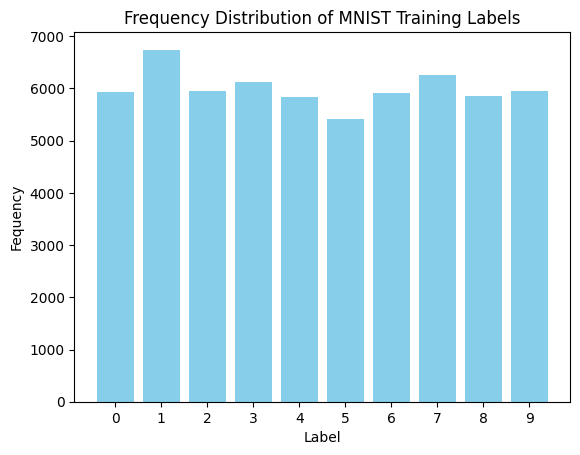

In [ ]:
import matplotlib.pyplot as plt

plt.bar(df['Label'], df['Frequency'], color='skyblue')
plt.xlabel('Label')
plt.ylabel('Fequency')
plt.title('Frequency Distribution of MNIST Training Labels')
plt.xticks(df['Label'])
plt.show()

### Sequential() 모델

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential(name="mys")
model.add(layers.Dense(512, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))

In [ ]:
model.weights

[]

In [ ]:
model.build((None, 28*28))
model.summary()

Model: "mys"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                     │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

(784*512) + 512 = 401,920 <-- 이게 dense_6의 경우의 param이다

In [ ]:
model.weights

[<Variable path=mys/dense_14/kernel, shape=(784, 512), dtype=float32, value=[[-1.2096066e-02 -2.5040027e-02  6.0566962e-02 ...  6.1664745e-02
    4.0253922e-03  1.1869326e-02]
  [-2.6602156e-02 -1.4739383e-02  5.5570744e-02 ... -2.0613730e-02
    3.4102403e-02  5.8966205e-02]
  [-2.4720576e-02  1.7024606e-02  2.8096199e-02 ...  4.1356832e-02
    1.1844233e-02  2.7770974e-02]
  ...
  [ 1.4194325e-02 -2.2718951e-02  5.6978419e-02 ...  8.9414418e-05
    4.0629804e-03  6.7121655e-02]
  [-3.6078673e-02  5.9976265e-02  3.4590304e-02 ... -6.5540373e-02
    2.8048813e-02 -4.9348176e-03]
  [-6.7716517e-02 -3.7961289e-02 -2.9651631e-02 ... -5.7500340e-02
   -4.0047176e-02 -1.8440895e-02]]>,
 <Variable path=mys/dense_14/bias, shape=(512,), dtype=float32, value=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0.

학습을 할 때 필요한 정보를 만들어야함 ex) 옵티마이저(경샤하강법), 손실함수(cost function), 모니터링 지표(error, accuracy 등)

In [ ]:
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

batch_size는 낮추면 낮출 수록 과적합 가능성 높아짐 --> 숫자가 높아지면 일반화가 됨

epochs는 학습 반복 횟수 이기에 높으면 높을 수록 과적합 가능성 높아짐

In [ ]:
train_images = train_images.reshape((60000, 28*28))
train_images = train_images.astype("float32")/255
test_images = test_images.reshape((10000, 28*28))
test_images = test_images.astype("float32")/255

In [ ]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8683 - loss: 0.4454
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9656 - loss: 0.1147
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9783 - loss: 0.0730
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9854 - loss: 0.0498
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9891 - loss: 0.0373


In [ ]:
model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0.0639213 , 0.08247197, 0.12002491, ..., 0.10773277, 0.07134533,
        0.23653755],
       [0.06759462, 0.0375249 , 0.16245721, ..., 0.07575132, 0.10088612,
        0.1853302 ],
       [0.08809225, 0.06483892, 0.13708824, ..., 0.0918408 , 0.10096027,
        0.15223624],
       ...,
       [0.04097245, 0.07013994, 0.12180083, ..., 0.20541127, 0.04610454,
        0.2702691 ],
       [0.06843914, 0.05707237, 0.16623792, ..., 0.12229659, 0.0868817 ,
        0.18048705],
       [0.05999951, 0.02871383, 0.21090086, ..., 0.08439616, 0.06204027,
        0.27743268]], dtype=float32)

test_loss, test_acc = model.evaluate(test_images, test_labels)
--> 여기서 test_images는 예측치 계산을위해, test_labels은실측치를 위한 값

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print("loss: ", test_loss)
print("acc: ", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1438 - loss: 2.3735
loss:  2.385047197341919
acc:  0.1477999985218048


model = keras.Sequential()

model.add(keras.Input(shape=(60000,28*28)))

model.add(keras.Dense(512, activation="relu"))

model.add(keras.Dense(10, activation="softmax"))

In [108]:
# model = keras.Sequential()
# model.add(keras.Input(shape=(28*28,)))  #batch_size = 샘플수 / batch_size
# model.add(keras.Dense(512, activation="relu"))
# model.add(keras.Dense(10, activation="softmax"))

### 함수형 API

In [111]:
inputs = keras.Input(shape=(28*28,))
hidden_1 = layers.Dense(512, activation="relu")(inputs)
outputs = layers.Dense(10, activation="softmax")(hidden_1)

model2 = keras.Model(inputs=inputs, outputs=outputs)

inputs.shape를 실행하여 데이터의 형태를 확인해야한다

In [112]:
inputs.shape

(None, 784)

In [113]:
model2.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_34 (InputLayer)          │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [118]:
vocabulary_size = 1000
num_tags = 100
num_departments = 4

In [119]:
title = keras.Input(shape=(vocabulary_size,), name="title")
text_body=keras.Input(shape=(vocabulary_size,))
tags = keras.Input(shape=(num_tags,))

features = layers.Concatenate()([title, text_body, tags])
hidden_1 = layers.Dense(64, activation="relu")(features)

priority = layers.Dense(1, activation="sigmoid")(hidden_1)
department = layers.Dense(num_departments, activation="softmax", name="department")(hidden_1)

model = keras.Model(inputs=[title, text_body, tags], outputs=[priority, department])

In [122]:
from tensorflow.keras import utils

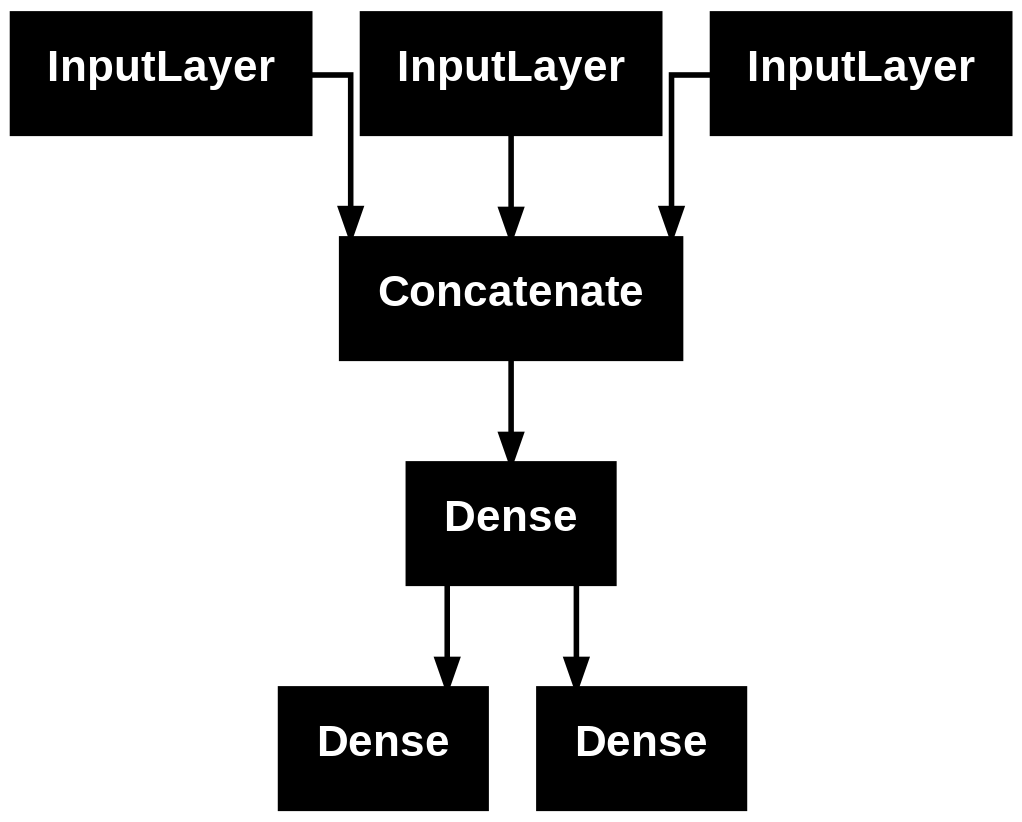

In [123]:
utils.plot_model(model,"test.png")